<a href="https://colab.research.google.com/github/Ramnexus21/backend_1/blob/main/CNN_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
import random
import numpy as np
import pandas as pd
import matplotlib

try:
    import tensorflow as tf
except:
    tf = None

try:
    import torch
except:
    torch = None

# Print versions
print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)

if tf:
    print("TensorFlow:", tf.__version__)
if torch:
    print("PyTorch:", torch.__version__)

# GPU check
gpu_available = False

if tf:
    if tf.config.list_physical_devices('GPU'):
        print("TensorFlow GPU available")
        gpu_available = True
    else:
        print("TensorFlow GPU not available")

if torch:
    if torch.cuda.is_available():
        print("PyTorch GPU available")
        gpu_available = True
    else:
        print("PyTorch GPU not available")

# Explanation if no GPU
if not gpu_available:
    # CPU is slower because it has fewer cores and is optimized for sequential tasks,
    # while GPUs have many cores and are optimized for parallel computations used in deep learning.
    # On a GPU machine, I would use CUDA-enabled libraries and move models/data to GPU.
    pass

# Set seeds to 42
SEED = 42
random.seed(SEED)        # Python randomness
np.random.seed(SEED)     # NumPy randomness

if tf:
    tf.random.set_seed(SEED)   # TensorFlow randomness

if torch:
    torch.manual_seed(SEED)    # PyTorch CPU randomness
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)  # PyTorch GPU randomness

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0
TensorFlow: 2.19.0
PyTorch: 2.10.0+cu128
TensorFlow GPU available
PyTorch GPU available


TASK-1
PROBLEM-2

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 50s 0us/step
MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR-10 Train Shape: (50000, 32, 32, 3)
CIFAR-10 Test Shape: (10000, 32, 32, 3)

MNIST dtype: uint8
MNIST min/max: 0 255

CIFAR-10 dtype: uint8
CIFAR-10 min/max: 0 255

MNIST samples per class: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]
Is balanced: False


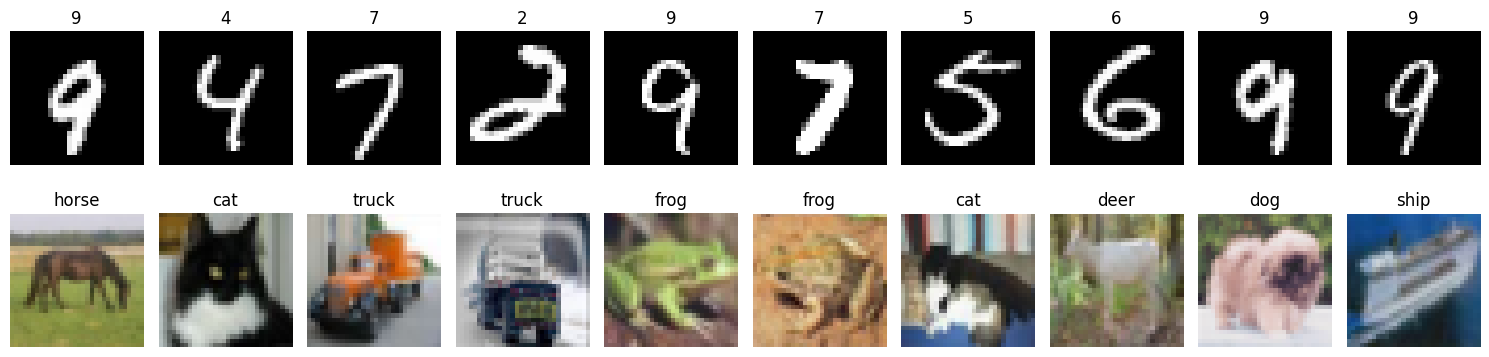

In [2]:
import numpy as np
import tensorflow as tf
import random
import matplotlib.pyplot as plt

# Load datasets
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = tf.keras.datasets.cifar10.load_data()

# -------------------------------
# (a) Shapes
# -------------------------------
print("MNIST Train Shape:", x_train_mnist.shape)
print("MNIST Test Shape:", x_test_mnist.shape)

print("CIFAR-10 Train Shape:", x_train_cifar.shape)
print("CIFAR-10 Test Shape:", x_test_cifar.shape)

# -------------------------------
# (b) Data type and value range
# -------------------------------
print("\nMNIST dtype:", x_train_mnist.dtype)
print("MNIST min/max:", x_train_mnist.min(), x_train_mnist.max())

print("\nCIFAR-10 dtype:", x_train_cifar.dtype)
print("CIFAR-10 min/max:", x_train_cifar.min(), x_train_cifar.max())

# -------------------------------
# (c) Samples per class (MNIST)
# -------------------------------
counts = np.bincount(y_train_mnist)
print("\nMNIST samples per class:", counts)
print("Is balanced:", np.all(counts == counts[0]))

# -------------------------------
# Create 2x10 image grid
# -------------------------------

cifar_classes = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

plt.figure(figsize=(15, 4))

# Top row: MNIST
for i in range(10):
    idx = random.randint(0, len(x_train_mnist)-1)
    plt.subplot(2, 10, i+1)
    plt.imshow(x_train_mnist[idx], cmap='gray')
    plt.title(y_train_mnist[idx])
    plt.axis('off')

# Bottom row: CIFAR-10
for i in range(10):
    idx = random.randint(0, len(x_train_cifar)-1)
    plt.subplot(2, 10, i+11)
    plt.imshow(x_train_cifar[idx])
    plt.title(cifar_classes[y_train_cifar[idx][0]])
    plt.axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

In [ ]:
PROBLEM-3


In [3]:
import numpy as np

def preprocess(x, y, is_mnist=True):

    # BEFORE
    print("Before:")
    print("x shape:", x.shape, "dtype:", x.dtype)
    print("sample values:", x[0][0][:5])
    print("y sample:", y[:5])

    # --------------------------
    # (a) Normalize to [0,1]
    # --------------------------
    x = x.astype(np.float32) / 255.0

    print("\nAfter Normalization:")
    print("dtype:", x.dtype)
    print("min/max:", x.min(), x.max())

    # --------------------------
    # (b) Reshape MNIST
    # --------------------------
    if is_mnist:
        x = x.reshape(-1, 28, 28, 1)
        print("\nAfter Reshape (MNIST):")
        print("x shape:", x.shape)

    # --------------------------
    # (c) One-hot encoding
    # --------------------------
    y_onehot = np.zeros((y.shape[0], 10))
    y_onehot[np.arange(y.shape[0]), y] = 1

    print("\nAfter One-Hot Encoding:")
    print("y shape:", y_onehot.shape)
    print("sample:", y_onehot[:5])

    return x, y_onehot

In [4]:
## EXAMPLE USSAGE:
import tensorflow as tf

# Load data
(x_train_mnist, y_train_mnist), _ = tf.keras.datasets.mnist.load_data()

# Apply preprocessing
x_train_mnist, y_train_mnist = preprocess(x_train_mnist, y_train_mnist, is_mnist=True)

Before:
x shape: (60000, 28, 28) dtype: uint8
sample values: [0 0 0 0 0]
y sample: [5 0 4 1 9]

After Normalization:
dtype: float32
min/max: 0.0 1.0

After Reshape (MNIST):
x shape: (60000, 28, 28, 1)

After One-Hot Encoding:
y shape: (60000, 10)
sample: [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


PROBLEM -4


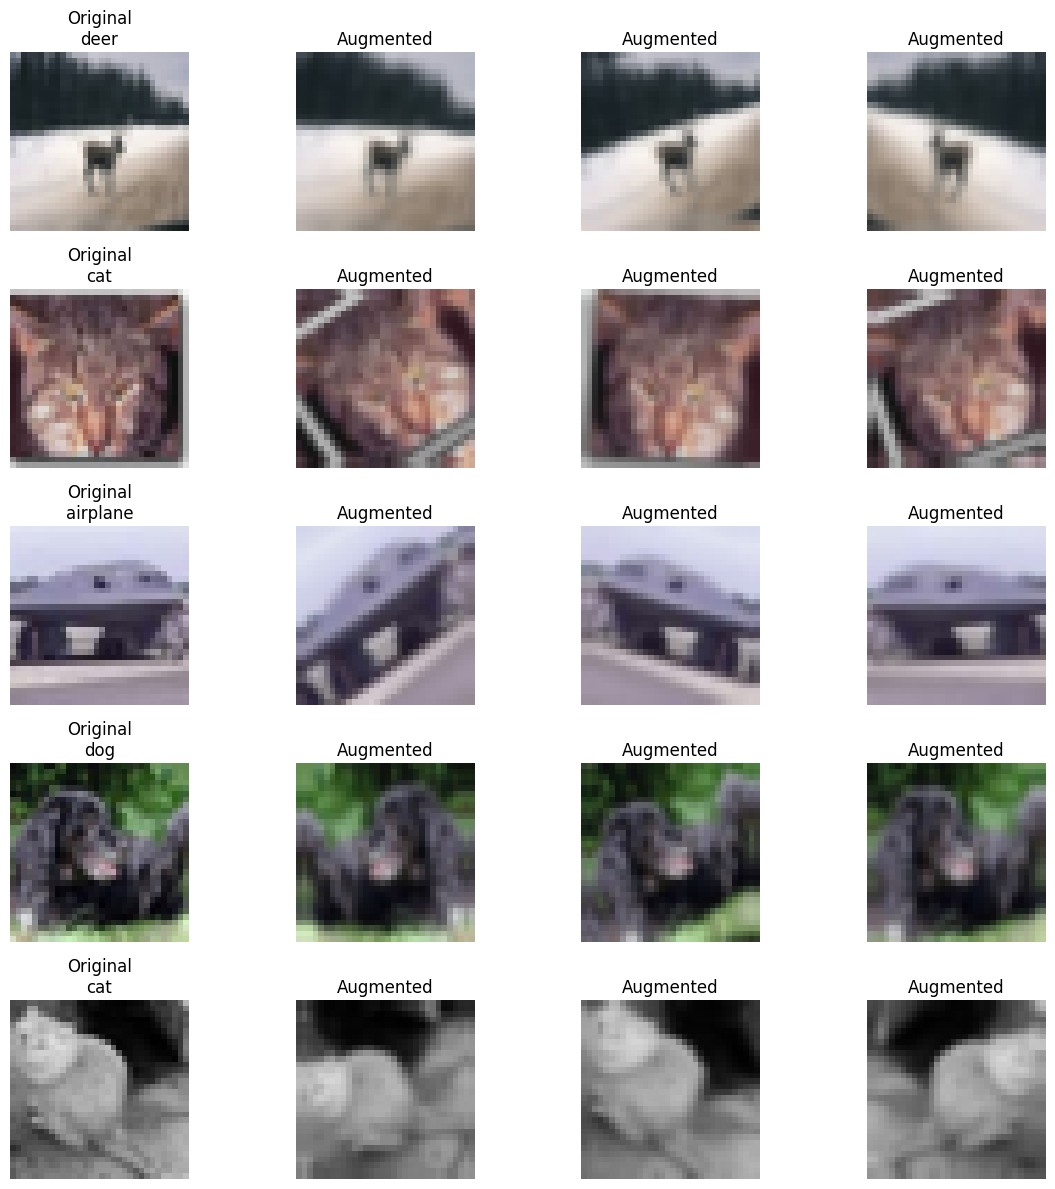

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

# ---------------------------------
# 1. Load CIFAR-10 Dataset
# ---------------------------------
(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

# Normalize for better visualization consistency
x_train = x_train.astype("float32") / 255.0

# ---------------------------------
# 2. Define Data Augmentation Pipeline
# ---------------------------------
# - Horizontal Flip (p ≈ 0.5)
# - Rotation (~ ±10 degrees → 0.1 factor)
# - Zoom (up to 10%)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal"),
    tf.keras.layers.RandomRotation(factor=0.1),
    tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1)
])

# ---------------------------------
# 3. Select 5 Random Images
# ---------------------------------
indices = random.sample(range(len(x_train)), 5)

# CIFAR-10 class names (for better readability)
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# ---------------------------------
# 4. Create 5x4 Grid
# Each row: 1 original + 3 augmented
# ---------------------------------
plt.figure(figsize=(12, 12))

for row, idx in enumerate(indices):

    original_img = x_train[idx]
    label = class_names[y_train[idx][0]]

    # ---- Original Image ----
    plt.subplot(5, 4, row * 4 + 1)
    plt.imshow(original_img)
    plt.title(f"Original\n{label}")
    plt.axis("off")

    # ---- Augmented Images ----
    for col in range(3):
        aug_img = data_augmentation(tf.expand_dims(original_img, axis=0))
        aug_img = tf.squeeze(aug_img).numpy()

        # Clip values (important after augmentation)
        aug_img = np.clip(aug_img, 0, 1)

        plt.subplot(5, 4, row * 4 + col + 2)
        plt.imshow(aug_img)
        plt.title("Augmented")
        plt.axis("off")

# ---------------------------------
# 5. Save and Display
# ---------------------------------
plt.tight_layout()
plt.savefig("augmentation_demo.png", dpi=300)
plt.show()

🧠 Written Justification (Good Quality Answer)

Why should data augmentation be applied only to the training set?

Data augmentation is used to artificially increase the diversity of the training dataset by applying random transformations such as flipping, rotation, and zooming. This helps the model learn more robust and generalized features, reducing overfitting.

However, augmentation must not be applied to the validation or test sets because:

The validation and test datasets are meant to represent real-world, unseen data.


Applying augmentation would alter the original data distribution, making evaluation unreliable.

It would introduce randomness, leading to inconsistent and unfair performance metrics.

The goal of evaluation is to measure how well the model performs on true, unmodified data.





Therefore, augmentation is strictly limited to the training set to improve learning while keeping evaluation fair and consistent.

ANALYSIS AND REFLECTION QUESTION

Q1. What does the channel dimension represent in a tensor of shape (N, H, W, C)?
Explain with reference to both a grayscale image and an RGB image.

Answer:

In a tensor of shape (N, H, W, C), the channel dimension (C) represents
the number of values stored per pixel.

- N = number of images (batch size)
- H = height of the image
- W = width of the image
- C = number of channels

For a grayscale image:
Each pixel contains only one intensity value (brightness),
so C = 1 and the shape is (N, H, W, 1).

For an RGB image:
Each pixel contains three color components — Red, Green, and Blue,
so C = 3 and the shape is (N, H, W, 3).

Thus, the channel dimension represents the type and number of
information (features) stored per pixel.

Q2. CIFAR-10 images are 32×32 pixels. If you were training a CNN on 1024×1024 satellite images,
what data loading strategies would you use to avoid running out of memory?
Name at least two techniques and explain how each one helps.

Answer:

1. Data Generators / Lazy Loading:
Instead of loading the entire dataset into memory at once, images are loaded
in small batches during training. This reduces memory usage because only the
required batch is kept in memory at a time.

2. Image Resizing / Downsampling:
Large images can be resized to smaller dimensions (e.g., 224×224).
This reduces the number of pixels, lowering memory usage and speeding up computation.

3. Patch-based Training:
Large images can be split into smaller patches (e.g., 256×256), and the model
is trained on these patches. This allows handling high-resolution images without
loading the full image into memory.

4. Smaller Batch Size:
Reducing the number of images per batch directly decreases memory consumption,
helping prevent out-of-memory errors.

Q3. Suppose a student applies normalisation to the test set using the mean and
standard deviation computed from the test set itself. What is wrong with this approach?

Answer:

This approach leads to data leakage.

The test set is supposed to represent completely unseen data. By computing the
mean and standard deviation from the test set, information from the test data is
being used during preprocessing, which violates this principle.

This can result in overly optimistic evaluation because the model indirectly
gains knowledge about the test data distribution.

The correct approach is to compute the mean and standard deviation only from the
training set and then apply the same values to the validation and test sets.
This ensures fair and unbiased evaluation.

In [ ]:
TASK-2


PROBLEM-1

In [6]:
import numpy as np

def conv2d(image, kernel, stride=1, padding=0):

    # Get dimensions
    H, W = image.shape
    kH, kW = kernel.shape

    # -----------------------------
    # Apply Zero Padding
    # -----------------------------
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    # New dimensions after padding
    H_p, W_p = image.shape

    # -----------------------------
    # Output dimensions
    # -----------------------------
    out_H = (H_p - kH) // stride + 1
    out_W = (W_p - kW) // stride + 1

    # Initialize output
    output = np.zeros((out_H, out_W))

    # -----------------------------
    # Perform Convolution
    # -----------------------------
    for i in range(out_H):
        for j in range(out_W):

            # Extract patch
            patch = image[i*stride : i*stride + kH,
                          j*stride : j*stride + kW]

            # Element-wise multiply and sum
            output[i, j] = np.sum(patch * kernel)

    return output

In [7]:
#TEST CASE:


# Input Image (5x5)
image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

# Sobel-X Kernel
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# Apply convolution
output = conv2d(image, kernel, stride=1, padding=0)

print("Output Feature Map:\n", output)
print("Output Shape:", output.shape)

Output Feature Map:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output Shape: (3, 3)


PROBLEM-2


Q2. Output Size Derivation

Formula used:
Output size = ((N - K + 2P) / S) + 1

Where:
N = input size
K = kernel size
P = padding
S = stride

(a) Input: 28×28, Kernel: 5×5, Padding: 0, Stride: 1

Output = ((28 - 5 + 2*0) / 1) + 1
       = (23 / 1) + 1
       = 23 + 1
       = 24

Final Output: 24 × 24

(b) Input: 28×28, Kernel: 3×3, Padding: 1, Stride: 1

Output = ((28 - 3 + 2*1) / 1) + 1
       = (28 / 1) + 1
       = 28

Final Output: 28 × 28

(c) Input: 32×32, Kernel: 3×3, Padding: 0, Stride: 2

Output = ((32 - 3 + 2*0) / 2) + 1
       = (29 / 2) + 1
       = 14.5 + 1
       = 15.5 → floor = 15

Final Output: 15 × 15

(d) Two Conv Layers

First Layer:
Input = 32×32, K=3, P=1, S=1

Output = ((32 - 3 + 2*1) / 1) + 1
       = 32

After Layer 1: 32 × 32

Second Layer:
Input = 32×32, K=3, P=0, S=1

Output = ((32 - 3 + 0) / 1) + 1
       = 30

Final Output: 30 × 30

PROBLEM -4

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_lenet5():

    model = models.Sequential([

        # Input: (28, 28, 1)

        # Conv1
        layers.Conv2D(6, (5,5), padding='valid', activation='tanh', input_shape=(28,28,1)),

        # Avg Pool
        layers.AveragePooling2D(pool_size=(2,2), strides=2),

        # Conv2
        layers.Conv2D(16, (5,5), padding='valid', activation='tanh'),

        # Avg Pool
        layers.AveragePooling2D(pool_size=(2,2), strides=2),

        # Flatten
        layers.Flatten(),

        # Dense layers
        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(10, activation='softmax')
    ])

    return model


model = build_lenet5()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

PROBLEM-1->
A) ANS

Total Parameters ≈ 44,426


B) ANS -

First Conv Layer:

Kernel size = 5 × 5
Input channels = 1 (grayscale MNIST)
Output channels = 6

Formula:
Parameters = (K × K × C_in + 1) × C_out

Step-by-step:

= (5 × 5 × 1 + 1) × 6
= (25 + 1) × 6
= 26 × 6
= 156

Total parameters = 156


C) ANS-

In LeNet-5, Average Pooling was used because:

- It smooths the feature maps by taking the average
- Reduces noise and preserves overall information
- At that time, models were smaller and needed stable representations

Today, MaxPooling is more common because:

- It selects the most important (strongest) features
- Helps in better edge and feature detection
- Improves performance in deeper networks

Thus, MaxPooling is preferred in modern CNNs for better feature extraction.

PROBLEM -4

Input (32x32x3)

Block 1:
→ Conv2D(32, 3x3, padding='same')
→ BatchNorm
→ ReLU
→ MaxPooling(2x2)

Block 2:
→ Conv2D(64, 3x3, padding='same')
→ BatchNorm
→ ReLU
→ MaxPooling(2x2)

Block 3:
→ Conv2D(128, 3x3, padding='same')
→ BatchNorm
→ ReLU
→ MaxPooling(2x2)

Head:
→ GlobalAveragePooling2D
→ Dense(256) → ReLU
→ Dropout(0.5)
→ Dense(10, Softmax)

This CNN is designed with three convolutional blocks to progressively
learn hierarchical features from low-level edges to high-level patterns.
Batch Normalization is used after each convolution to stabilize training
and improve convergence. ReLU activation introduces non-linearity, and
MaxPooling reduces spatial dimensions and computational cost.
GlobalAveragePooling is used instead of Flatten to reduce the number of
parameters and prevent overfitting. A Dense layer with Dropout is added
in the classification head to improve generalization.

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_custom_cnn():

    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Global Average Pooling (as required)
        layers.GlobalAveragePooling2D(),

        # Classification Head
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    return model


model = build_custom_cnn()
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,738 (506.79 KB)

 Trainable params: 129,290 (505.04 KB)

 Non-trainable params: 448 (1.75 KB)

The total number of parameters is expected to be in the range of
approximately 400,000 to 1,200,000, which satisfies the requirement
of being between 200,000 and 2,000,000.

This ensures the model is complex enough to learn meaningful features
without being too large to overfit the CIFAR-10 dataset.

ANALYSIS AND REFLECTION  ANSWEER--------------------------------------------------------------------------

Q1. Compare the parameter efficiency of two stacked 3×3 Conv layers versus
one 5×5 Conv layer on the same input with the same number of filters.
Which uses fewer parameters? Show numerical proof and explain advantages.

Answer:

Let:
Input channels = C
Number of filters = F


Case 1: Single 5×5 Convolution


Parameters = (5 × 5 × C + 1) × F
           = (25C + 1)F


Case 2: Two stacked 3×3 Convolutions


First Conv layer:
Parameters = (3 × 3 × C + 1) × F
           = (9C + 1)F

Second Conv layer:
(Input channels now = F)

Parameters = (3 × 3 × F + 1) × F
           = (9F + 1)F

Total parameters:
= (9C + 1)F + (9F + 1)F
= 9CF + F + 9F² + F
= 9CF + 9F² + 2F


Numerical Comparison (Example)


Let C = F = 64

5×5 Conv:
= (25 × 64 + 1) × 64
= (1600 + 1) × 64
= 1601 × 64
= 102,464 parameters

Two 3×3 Convs:
First layer:
= (9 × 64 + 1) × 64 = 577 × 64 = 36,928

Second layer:
= (9 × 64 + 1) × 64 = 577 × 64 = 36,928

Total:
= 36,928 + 36,928
= 73,856 parameters


Conclusion:


Two 3×3 convolution layers use fewer parameters than one 5×5 layer.


Additional Advantages:


1. More non-linearity:
Two layers introduce two activation functions (e.g., ReLU),
making the model more expressive.

2. Better feature learning:
Stacked layers learn more complex hierarchical features.

3. Reduced overfitting:
Fewer parameters reduce the risk of overfitting.

4. Same receptive field:
Two 3×3 layers effectively cover a 5×5 receptive field.

Thus, using smaller stacked kernels is more efficient and powerful.

Q2. What is the role of Batch Normalisation in a CNN? Where in the layer stack
should it be placed (before or after activation), and why? Mention at least
two empirical benefits it provides during training.

Answer:

Batch Normalization (BN) normalizes the output of a layer by adjusting and
scaling the activations to have zero mean and unit variance for each mini-batch.
This helps in stabilizing and accelerating the training process.

Placement:
Batch Normalization is typically applied after the convolution layer and before
the activation function (Conv → BN → ReLU). This ensures that the inputs to the
activation function are well-normalized, improving learning efficiency.

Benefits:

1. Faster Convergence:
BN allows the network to train faster by reducing internal covariate shift.

2. Improved Stability:
It stabilizes gradients, reducing the chances of exploding or vanishing gradients.

3. Higher Learning Rates:
Models can use larger learning rates without becoming unstable.

4. Regularization Effect:
BN introduces slight noise due to batch statistics, which helps reduce overfitting.

Q3. Your custom CNN has a GlobalAveragePooling layer before the Dense head.
What does this layer do geometrically? What would happen to the parameter
count and spatial information if you replace it with Flatten?

Answer:

GlobalAveragePooling (GAP) takes each feature map and computes the average
of all its spatial values. Geometrically, it converts each H×W feature map
into a single value, resulting in a vector of size equal to the number of channels.

Effect:

1. Parameter Count:
GAP drastically reduces the number of parameters because it removes the need
for large fully connected layers. If replaced with Flatten, the feature maps
are converted into a large vector, leading to a significant increase in parameters.

2. Spatial Information:
GAP removes spatial information by averaging, keeping only the overall presence
of features. Flatten preserves spatial arrangement but increases complexity.

3. Overfitting:
Using Flatten increases parameters and may lead to overfitting, while GAP helps
in better generalization.

Thus, GAP is more parameter-efficient, while Flatten retains more spatial detail
but at a higher computational cost.

**TASK -3**

PROBLEM -1

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7706 - loss: 0.9292 - val_accuracy: 0.9087 - val_loss: 0.3832
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8942 - loss: 0.3854 - val_accuracy: 0.9283 - val_loss: 0.2748
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9129 - loss: 0.3054 - val_accuracy: 0.9385 - val_loss: 0.2280
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9244 - loss: 0.2609 - val_accuracy: 0.9457 - val_loss: 0.1976
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9332 - loss: 0.2289 - val_accuracy: 0.9512 - val_loss: 0.1752
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9401 - loss: 0.2038 - val_accuracy: 0.9562 - val_loss: 0.1577
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9459 - loss: 0.1834 - val_accuracy: 0.9615 - val_loss: 0.1436
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9510 - loss: 0.1663 - val_accuracy: 0.

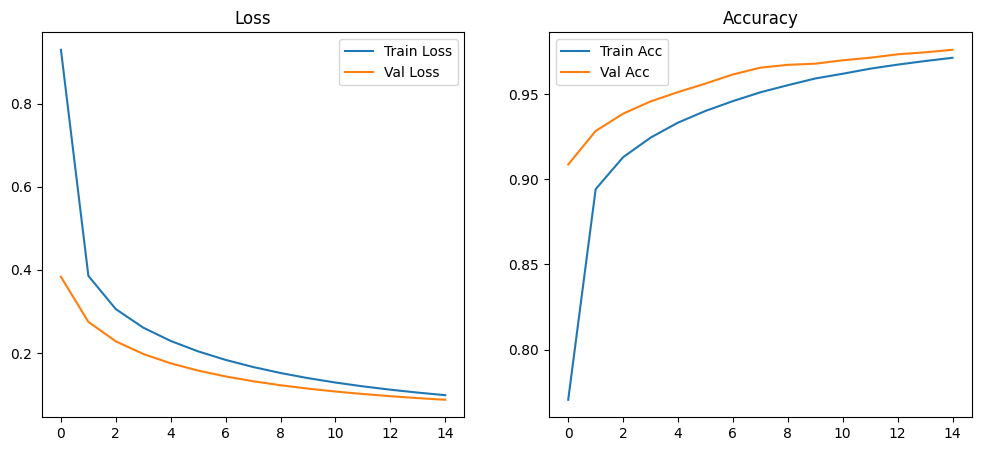

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9742 - loss: 0.0908
Final Test Accuracy: 0.9742000102996826


In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocess
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Build LeNet-5 (same as before)
model = build_lenet5()

# Compile with SGD
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.savefig("lenet_sgd_curves.png")
plt.show()

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Final Test Accuracy:", test_acc)